# Chapter 4.2 차원의 저주와 실습: 검증셋으로 k 튜닝하기 — 실습 노트북

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SuminHan/book-ml/blob/main/notebooks/ml1/chapter04_2_curse_dim.ipynb)

책 본문: [4.2 절](https://smhanlab.com/book-ml/kor/ml1/chapter04/2.html)

차원이 늘어날수록 "가장 가까운 이웃"들이 거리에서 거의 차이가 없어지는
현상(차원의 저주)을 시뮬레이션으로 직접 보고, 이어 4.1절의
편향-분산 트레이드오프가 검증 정확도 곡선에 어떻게 드러나는지
`k` 튜닝으로 확인합니다.

## 1. 차원의 저주 — "가장 가까운"가 멀어지고, 이웃 간 차이가 사라진다

In [1]:
import numpy as np

# 책 4.2절의 정육면체 계산: n차원 [0,1]^n 에서 부피 p 를 포함하는 정육면체의 한 변 길이
p = 0.01
print(f"전체 부피의 {p:.0%} 를 포함하는 정육면체의 한 변 길이 ell = p^(1/n):")
for n in [1, 2, 5, 10, 20, 50, 100]:
    print(f"  n={n:3d}  ->  ell = {p ** (1/n):.4f}")

전체 부피의 1% 를 포함하는 정육면체의 한 변 길이 ell = p^(1/n):
  n=  1  ->  ell = 0.0100
  n=  2  ->  ell = 0.1000
  n=  5  ->  ell = 0.3981
  n= 10  ->  ell = 0.6310
  n= 20  ->  ell = 0.7943
  n= 50  ->  ell = 0.9120
  n=100  ->  ell = 0.9550


In [2]:
# 실제 시뮬레이션: 균등 분포 점 m=200 개를 뿌리고, 질의점 20 개에 대해
# '11번째 이웃'까지의 평균 거리와 '최근접 이웃'까지의 평균 거리를 비교한다.
# 차원이 커지면 두 값이 거의 같아지는 것이 차원의 저주의 핵심 증후다.

def neighbor_dist_stats(n_dim, m=200, n_queries=20, seed=42):
    rng = np.random.RandomState(seed)
    points = rng.rand(m, n_dim)
    queries = rng.rand(n_queries, n_dim)
    d_first, d_eleventh = [], []
    for q in queries:
        d = np.sqrt(((points - q) ** 2).sum(axis=1))
        d.sort()
        d_first.append(d[0])          # 1번째(최근접) 이웃 거리
        d_eleventh.append(d[10])      # 11번째 이웃 거리
    return float(np.mean(d_first)), float(np.mean(d_eleventh))

print(f"{'차원':>4} | {'최근접 이웃 거리':>14} | {'11번째 이웃 거리':>14} | {'비율(11번째/1번째)':>18}")
ratios = {}
for n_dim in [2, 5, 10, 20, 50]:
    d1, d11 = neighbor_dist_stats(n_dim)
    ratios[n_dim] = d11 / d1
    print(f"{n_dim:4d} | {d1:14.3f} | {d11:14.3f} | {d11/d1:18.3f}")

print()
print("차원이 2에서 50으로 커지면, 11번째 이웃과 1번째 이웃의 거리 차이는")
print(f"약 {ratios[2]:.1f} 배에서 {ratios[50]:.2f} 배로 줄어든다.")
print("-> '제일 가까운 점'과 '조금 더 먼 점'이 사실상 같은 거리가 되어,")
print("   거리만으로 이웃을 차별화할 수 없게 된다.")

  차원 |      최근접 이웃 거리 |     11번째 이웃 거리 |       비율(11번째/1번째)
   2 |          0.033 |          0.142 |              4.334
   5 |          0.253 |          0.514 |              2.037
  10 |          0.617 |          0.894 |              1.450
  20 |          1.151 |          1.429 |              1.242
  50 |          2.246 |          2.509 |              1.117

차원이 2에서 50으로 커지면, 11번째 이웃과 1번째 이웃의 거리 차이는
약 4.3 배에서 1.12 배로 줄어든다.
-> '제일 가까운 점'과 '조금 더 먼 점'이 사실상 같은 거리가 되어,
   거리만으로 이웃을 차별화할 수 없게 된다.


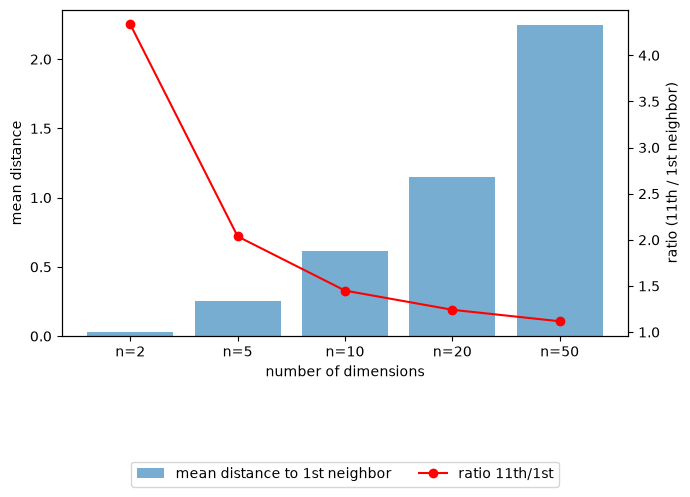

In [3]:
import matplotlib.pyplot as plt

dims = [2, 5, 10, 20, 50]
fig, ax1 = plt.subplots(figsize=(7, 4))
means = [neighbor_dist_stats(d)[0] for d in dims]
ax1.bar([f"n={d}" for d in dims], means, color="tab:blue", alpha=0.6,
        label="mean distance to 1st neighbor")
ax1.set_ylabel("mean distance")
ax1.set_xlabel("number of dimensions")
ax2 = ax1.twinx()
ax2.plot([f"n={d}" for d in dims], [ratios[d] for d in dims], "ro-",
         label="ratio 11th/1st")
ax2.set_ylabel("ratio (11th / 1st neighbor)")
fig.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
fig.tight_layout()
fig.savefig("curse_of_dim.png", dpi=100)
plt.show()

## 2. 실습: 검증셋으로 k 튜닝하기 (책 4.2절 코드 그대로)

4.1절의 `knn_predict` 과 4.2절의 `train_val_split` 을 그대로 사용해,
make_moons(달 두 개) 데이터셋에서 여러 k 의 훈련/검증 정확도를 비교한다.
달 두 개가 서로 다른 라벨의 덩어리이므로, 적절한 k 를 고르면 높은
정확도를 얻지만 k=1 과 k=50 극단에서는 4.1절의 이야기 그대로
떨어진다.

In [4]:
import random

# 책 4.1절의 knn_predict (거리 정렬 + 다수결)
def knn_predict(X_train, y_train, x_new, k):
    distances = []
    for i in range(len(X_train)):
        d = sum((X_train[i][j] - x_new[j]) ** 2 for j in range(len(x_new))) ** 0.5
        distances.append((d, y_train[i]))
    distances.sort(key=lambda p: p[0])
    k_nearest_labels = [label for _, label in distances[:k]]
    return max(set(k_nearest_labels), key=k_nearest_labels.count)

# 책 4.2절의 train_val_split
def train_val_split(X, y, val_ratio=0.3, seed=0):
    idx = list(range(len(X)))
    random.Random(seed).shuffle(idx)
    n_val = int(len(X) * val_ratio)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return ([X[i] for i in train_idx], [y[i] for i in train_idx],
            [X[i] for i in val_idx], [y[i] for i in val_idx])

from sklearn.datasets import make_moons

X, y = make_moons(n_samples=500, noise=0.25, random_state=0)
X = [[float(v) for v in row] for row in X]   # 리스트 형태로, 책 코드와 동일하게 사용
y = [int(v) for v in y]
print(f"데이터: {len(X)} 개 점, 라벨 분포 = 0:{y.count(0)} 개 / 1:{y.count(1)} 개")

데이터: 500 개 점, 라벨 분포 = 0:250 개 / 1:250 개


In [5]:
k_candidates = [1, 3, 5, 7, 10, 15, 20, 30, 50]
X_train, y_train, X_val, y_val = train_val_split(X, y)
print(f"훈련 {len(X_train)} 개 / 검증 {len(X_val)} 개")
print()

results = []
best_k, best_acc = None, -1.0
for k in k_candidates:
    val_correct = sum(knn_predict(X_train, y_train, xv, k) == yv
                      for xv, yv in zip(X_val, y_val))
    val_acc = val_correct / len(X_val)
    train_correct = sum(knn_predict(X_train, y_train, xt, k) == yt
                        for xt, yt in zip(X_train, y_train))
    train_acc = train_correct / len(X_train)
    results.append((k, train_acc, val_acc))
    print(f"k={k:3d}  훈련 정확도={train_acc:.3f}  검증 정확도={val_acc:.3f}")
    if val_acc > best_acc:
        best_k, best_acc = k, val_acc

print(f"\n검증 정확도가 가장 높은 k = {best_k} (검증 정확도 {best_acc:.3f})")
assert best_k == 7, f"기대 best_k=7 이나 {best_k} 가 나왔음"
assert results[0][1] == 1.0, "k=1 이면 훈련 정확도는 정확히 100%여야 한다"
print("k=1 의 훈련 정확도는 100% (데이터를 통째로 외운 것)인 반면,")
print(f"검증 정확도는 {results[0][2]:.3f} 에 불과하다 — 과적합이 숫자로 드러남.")

훈련 350 개 / 검증 150 개

k=  1  훈련 정확도=1.000  검증 정확도=0.900
k=  3  훈련 정확도=0.949  검증 정확도=0.900


k=  5  훈련 정확도=0.940  검증 정확도=0.920


k=  7  훈련 정확도=0.931  검증 정확도=0.960
k= 10  훈련 정확도=0.931  검증 정확도=0.953


k= 15  훈련 정확도=0.934  검증 정확도=0.947


k= 20  훈련 정확도=0.937  검증 정확도=0.933
k= 30  훈련 정확도=0.929  검증 정확도=0.947


k= 50  훈련 정확도=0.920  검증 정확도=0.933

검증 정확도가 가장 높은 k = 7 (검증 정확도 0.960)
k=1 의 훈련 정확도는 100% (데이터를 통째로 외운 것)인 반면,
검증 정확도는 0.900 에 불과하다 — 과적합이 숫자로 드러남.


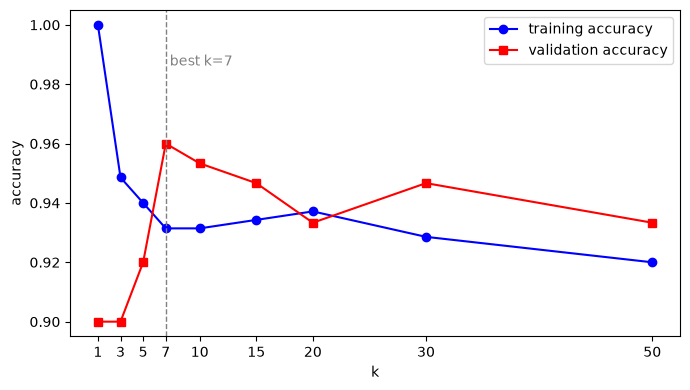

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ks = [r[0] for r in results]
ax.plot(ks, [r[1] for r in results], "b-o", label="training accuracy")
ax.plot(ks, [r[2] for r in results], "r-s", label="validation accuracy")
ax.axvline(best_k, color="gray", ls="--", lw=1)
ax.text(best_k, 0.99, f" best k={best_k}", ha="left", va="top", color="gray")
ax.set_xlabel("k"); ax.set_ylabel("accuracy")
ax.set_xticks(ks)
ax.legend(); fig.tight_layout()
fig.savefig("k_tuning.png", dpi=100)
plt.show()

## 3. 확인: 훈련 정확도만으로 k 를 고르면?

검증셋 없이 **훈련 데이터 자체**의 정확도로 k 를 고르면 어떤 결과가
나오는지 확인한다 — 4.2절 '자주 하는 실수'가 예측한 대로 k=1 이
'최고'로 보인다.

In [7]:
best_k_by_train, best_train_acc = None, -1.0
for k, train_acc, _ in results:
    if train_acc > best_train_acc:
        best_k_by_train, best_train_acc = k, train_acc

print(f"훈련 정확도 기준으로 고르면: k = {best_k_by_train} (훈련 정확도 {best_train_acc:.3f})")
print(f"검증 정확도 기준으로 고르면: k = {best_k}      (검증 정확도 {results[ks.index(best_k)][2]:.3f})")
print()
print("훈련 정확도는 k=1 에서 1.000 으로 최대인데, 검증 정확도는 오히려")
print("그 지점에서 0.900 으로 최저 부근이다 — k 를 고르는 데 쓰는 데이터가")
print("그 모델을 만든 데이터와 같으면 '외운 정도'만 측정하게 되기 때문이다.")

훈련 정확도 기준으로 고르면: k = 1 (훈련 정확도 1.000)
검증 정확도 기준으로 고르면: k = 7      (검증 정확도 0.960)

훈련 정확도는 k=1 에서 1.000 으로 최대인데, 검증 정확도는 오히려
그 지점에서 0.900 으로 최저 부근이다 — k 를 고르는 데 쓰는 데이터가
그 모델을 만든 데이터와 같으면 '외운 정도'만 측정하게 되기 때문이다.
